# Convergent-beam electron diffraction (CBED) of Bi$_2$Se$_3$

This tutorial runs the multislice **CBED simulator** in
[`ptyrodactyl.simul`](../../src/ptyrodactyl/simul/simulations.py) end-to-end on a
Bi$_2$Se$_3$ molecular-dynamics snapshot, using only the atomic coordinates shipped
in [`tests/test_data/bi2se3/`](../../tests/test_data/bi2se3).

The pipeline is:

1. **`parse_xyz`** &rarr; read atomic coordinates into a `CrystalData` PyTree.
2. **`kirkland_potentials_crystal`** &rarr; build projected-potential slices
   (Kirkland scattering factors, FFT sub-pixel placement, multislice partitioning).
3. **`make_probe`** + **`make_probe_modes`** &rarr; build a convergent electron probe.
4. **`cbed`** &rarr; propagate the probe through the slices and form the
   diffraction pattern.

> **Runs on CPU.** Everything here is sized to finish in a couple of minutes on a
> laptop CPU. The heaviest cell (potential generation) takes ~15 s; the thickness
> and temperature series take ~1 min each. On a GPU build of `jax` it is far faster.

In [1]:
import jax

# CBED uses Fresnel propagators and complex exponentials; run in double precision.
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from ptyrodactyl import simul
from ptyrodactyl.tools import (
    make_crystal_data,
    make_probe_modes,
    relativistic_wavelength_ang,
)

print("jax devices:", jax.devices())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


jax devices: [CpuDevice(id=0)]


## Simulation parameters

These are the knobs for the simulation. **Edit any of them and re-run the cells
below** &mdash; in particular the probe convergence semi-angle `aperture_mrad` and the
accelerating `voltage_kv`. Sections 3&ndash;4 (probe and CBED) depend only on these,
so after the potential is built once you can change the optics and re-run from
section 3 without rebuilding the potential.

In [2]:
# --- microscope optics (edit me) ---
voltage_kv = 200.0      # accelerating voltage (kV)
aperture_mrad = 20.0    # probe convergence semi-angle (mrad)
defocus_ang = 0.0       # probe defocus C1 (A); negative = underfocus

# --- sampling / multislice ---
pixel_size = 0.2        # real-space sampling (A / pixel)
slice_thickness = 2.0   # multislice step along the beam (A)
region_side = 40.0      # square (x, y) column of the slab to simulate (A)

## 1. Load the structure

`parse_xyz` reads an extended-XYZ file (the `Lattice="..."` comment line is parsed
too) and returns a `CrystalData` PyTree with `positions` (Å) and `atomic_numbers`.

The five files in `tests/test_data/bi2se3/` are MD snapshots of the same
Bi$_2$Se$_3$ slab at different temperatures; we start from `intial.xyz`.

In [3]:
# Resolve the data folder whether this notebook is run from its own directory
# or from the repository root.
_candidates = [
    Path("../../tests/test_data/bi2se3"),
    Path("tests/test_data/bi2se3"),
]
data_dir = next((p for p in _candidates if p.exists()), _candidates[0])

crystal = simul.parse_xyz(data_dir / "intial.xyz")

positions = np.asarray(crystal.positions)      # (N, 3) in Angstrom
numbers = np.asarray(crystal.atomic_numbers)   # (N,)  atomic numbers Z

print(f"{positions.shape[0]} atoms")
print("species (Z):", np.unique(numbers), " -> Se=34, Bi=83")
print("cell (A):\n", np.asarray(crystal.lattice))
print("x:", positions[:, 0].min(), positions[:, 0].max())
print("y:", positions[:, 1].min(), positions[:, 1].max())
print("z:", positions[:, 2].min(), positions[:, 2].max())

4000 atoms
species (Z): [34 83]  -> Se=34, Bi=83
cell (A):
 [[ 72.49155581   0.           0.        ]
 [  0.          41.31129508   0.        ]
 [  0.           0.         100.        ]]
x: 0.0557270104 72.5439210152
y: 0.3012709127 41.6124143253
z: 6.499112621 95.3965299913


The full cell (~72 x 41 Å in-plane, ~90 Å thick) is larger than we need for a quick
CBED demo, and being non-square it would make the central disk look elliptical in the
detector pixels. We carve out a **square ~40 x 40 Å column** through the full
thickness. This is the beam's-eye view: the electrons travel along $+z$.

In [4]:
def square_column(side_ang, z_thickness=None):
    # Select a square (x, y) column of atoms, optionally truncated in z.
    x0, y0, z0 = positions[:, 0].min(), positions[:, 1].min(), positions[:, 2].min()
    sel = (
        (positions[:, 0] >= x0) & (positions[:, 0] < x0 + side_ang)
        & (positions[:, 1] >= y0) & (positions[:, 1] < y0 + side_ang)
    )
    if z_thickness is not None:
        sel = sel & (positions[:, 2] < z0 + z_thickness)
    return make_crystal_data(
        positions=jnp.asarray(positions[sel]),
        atomic_numbers=jnp.asarray(numbers[sel]),
        lattice=crystal.lattice,
        stress=None,
        energy=None,
        properties=None,
        comment=None,
    ), int(sel.sum())


region, n_region = square_column(region_side)
print(f"{n_region} atoms in the {region_side:.0f} x {region_side:.0f} A column")

2144 atoms in the 40 x 40 A column


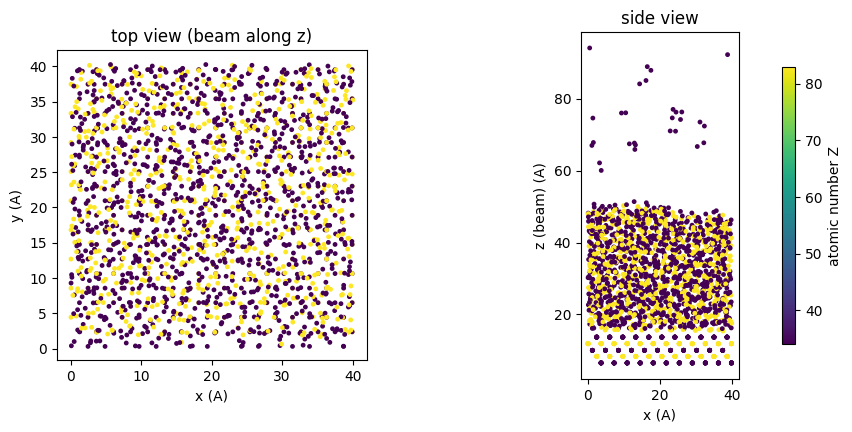

In [5]:
# Visualise the selected column: top view (beam's eye) and side view.
rpos = np.asarray(region.positions)
rZ = np.asarray(region.atomic_numbers)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sc = ax[0].scatter(rpos[:, 0], rpos[:, 1], c=rZ, cmap="viridis", s=6)
ax[0].set(title="top view (beam along z)", xlabel="x (A)", ylabel="y (A)", aspect="equal")
ax[1].scatter(rpos[:, 0], rpos[:, 2], c=rZ, cmap="viridis", s=6)
ax[1].set(title="side view", xlabel="x (A)", ylabel="z (beam) (A)", aspect="equal")
fig.colorbar(sc, ax=ax, label="atomic number Z", shrink=0.8)
plt.show()

## 2. Projected-potential slices

`kirkland_potentials_crystal` turns the atomic coordinates into a stack of 2-D
electrostatic potential slices (`PotentialSlices`). Key arguments:

- `pixel_size` — real-space sampling (Å/pixel). Finer sampling = larger reciprocal
  field of view in the CBED.
- `slice_thickness` — multislice step along $z$ (Å). Thinner = more accurate, slower.
- `padding` — vacuum border (Å) added before placing atoms, then cropped, to avoid
  FFT wrap-around.
- `supersampling` — internal oversampling when rasterising each atom's potential.

In [6]:
# pixel_size and slice_thickness come from the parameters cell above.
pot = simul.kirkland_potentials_crystal(
    region,
    pixel_size=pixel_size,
    slice_thickness=slice_thickness,
    padding=4.0,
    supersampling=4,
)

H, W, S = pot.slices.shape
print(f"potential grid: {H} x {W} pixels, {S} slices")
print(f"calibration: {float(pot.calib):.3f} A/px, slice thickness {float(pot.slice_thickness):.2f} A")

potential grid: 200 x 200 pixels, 44 slices
calibration: 0.200 A/px, slice thickness 2.00 A


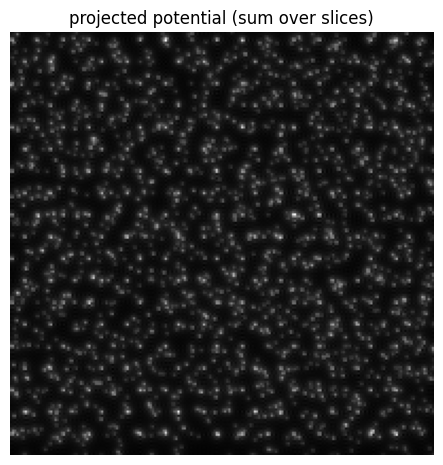

In [7]:
# Sum the slices to get the projected potential (what a phase-contrast image sees).
projected = np.asarray(pot.slices.sum(axis=2))

plt.figure(figsize=(5.5, 5.5))
plt.imshow(projected, cmap="gray")
plt.title("projected potential (sum over slices)")
plt.axis("off")
plt.show()

## 3. The convergent probe

`make_probe` builds the probe wavefunction from the aperture semi-angle and the
microscope aberrations, on the **same grid** as the potential (so the wave and the
transmission functions multiply element-wise). Note `calibration_pm` is in
**picometres**, hence `pixel_size * 100`.

`cbed` consumes a `ProbeModes` PyTree, so we wrap the single coherent probe with
`make_probe_modes` (one mode, weight 1).

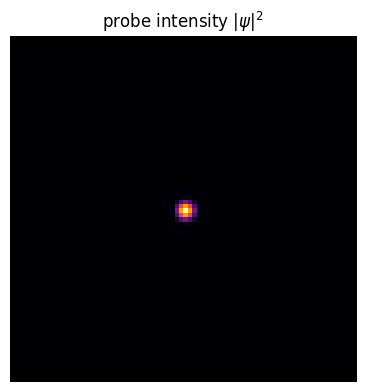

In [8]:
# voltage_kv, aperture_mrad and defocus_ang come from the parameters cell above.
probe = simul.make_probe(
    aperture=aperture_mrad,
    voltage=voltage_kv,
    image_size=jnp.array([H, W]),
    calibration_pm=pixel_size * 100.0,  # 0.2 A -> 20 pm
    defocus=defocus_ang,
)

beam = make_probe_modes(
    modes=probe[..., None],          # (H, W) -> (H, W, 1 mode)
    weights=jnp.array([1.0]),
    calib=pixel_size,
)

# Show the real-space probe intensity (central crop).
prb = np.abs(np.asarray(probe)) ** 2
cy, cx, r = H // 2, W // 2, 40
plt.figure(figsize=(4.5, 4.5))
plt.imshow(prb[cy - r:cy + r, cx - r:cx + r], cmap="inferno")
plt.title(r"probe intensity $|\psi|^2$")
plt.axis("off")
plt.show()

## 4. Simulate the CBED pattern

`cbed` runs the multislice algorithm — transmit through each slice, Fresnel-propagate
to the next — then takes the far-field intensity. It returns a `CalibratedArray` whose
`calib_y`/`calib_x` are the **reciprocal** sampling (Å$^{-1}$/pixel).

CBED shape: (200, 200)
wavelength = 2.508 pm,  detector half-width = 63 mrad


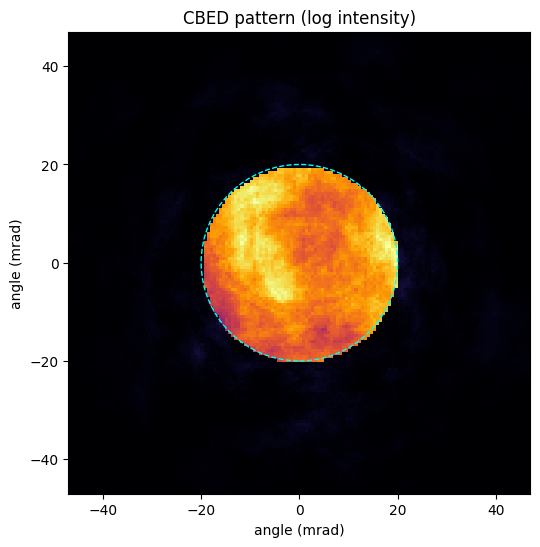

In [9]:
pattern = simul.cbed(pot_slices=pot, beam=beam, voltage_kv=voltage_kv)
cbed = np.asarray(pattern.data_array)
print("CBED shape:", cbed.shape)

# Convert the reciprocal axis to scattering angle (mrad) for labelling.
wavelength = float(relativistic_wavelength_ang(voltage_kv))   # Angstrom
q_per_px = float(pattern.calib_y)                             # 1 / A per pixel
half_mrad = (cbed.shape[0] / 2) * q_per_px * wavelength * 1e3
print(f"wavelength = {wavelength*100:.3f} pm,  detector half-width = {half_mrad:.0f} mrad")

# Central crop for display.
cy, cx, r = cbed.shape[0] // 2, cbed.shape[1] // 2, 75
crop = cbed[cy - r:cy + r, cx - r:cx + r]
ext = r * q_per_px * wavelength * 1e3   # mrad half-width of the crop

plt.figure(figsize=(6, 6))
plt.imshow(np.log1p(crop), cmap="inferno", extent=[-ext, ext, -ext, ext])
circ = plt.Circle((0, 0), aperture_mrad, color="cyan", fill=False, lw=1.0, ls="--")
plt.gca().add_patch(circ)
plt.title("CBED pattern (log intensity)")
plt.xlabel("angle (mrad)")
plt.ylabel("angle (mrad)")
plt.show()

The bright central disk is the convergent-beam disk; its radius matches the 20 mrad
aperture (dashed cyan). The intensity *inside* the disk is modulated by dynamical
scattering through the crystal, and the faint background is thermal-diffuse and
higher-order scattering.

## 5. CBED from different beam directions (side views)

The multislice solver always propagates the beam along **+z**, so to look at the
slab *from the side* we re-orient the coordinates: the chosen viewing axis becomes
the new beam ($z$) axis. Below we take a 40 Å cube and form a CBED looking down each
of the three crystal axes. The projected potential (top row) shows what the beam
"sees"; the CBED (bottom row) is the resulting diffraction pattern.

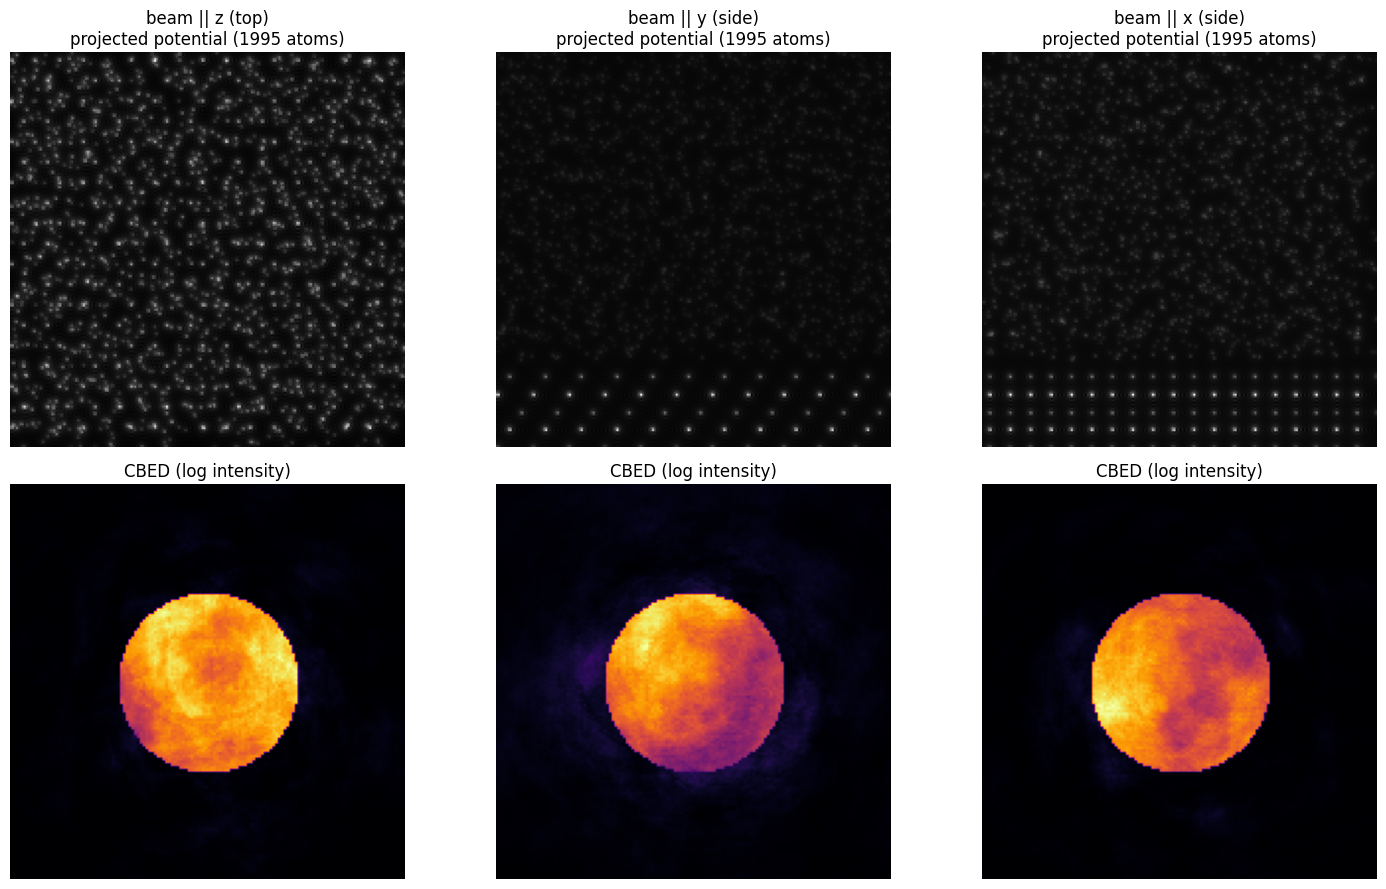

In [10]:
def oriented_column(view_axis, side, beam_thickness):
    # view_axis (0, 1, 2) is the original axis the beam travels along;
    # the other two axes become the in-plane (x, y) of the simulation.
    plane = [a for a in (0, 1, 2) if a != view_axis]
    pmin = positions.min(axis=0)
    sel = (
        (positions[:, plane[0]] >= pmin[plane[0]])
        & (positions[:, plane[0]] < pmin[plane[0]] + side)
        & (positions[:, plane[1]] >= pmin[plane[1]])
        & (positions[:, plane[1]] < pmin[plane[1]] + side)
        & (positions[:, view_axis] < pmin[view_axis] + beam_thickness)
    )
    new_pos = np.stack(
        [positions[sel, plane[0]], positions[sel, plane[1]], positions[sel, view_axis]],
        axis=1,
    )
    oriented = make_crystal_data(
        positions=jnp.asarray(new_pos),
        atomic_numbers=jnp.asarray(numbers[sel]),
        lattice=crystal.lattice,
        stress=None, energy=None, properties=None, comment=None,
    )
    return oriented, int(sel.sum())


views = [(2, "beam || z (top)"), (1, "beam || y (side)"), (0, "beam || x (side)")]
cube = region_side  # a (cube x cube x cube) A box, viewed from each direction

fig, axs = plt.subplots(2, len(views), figsize=(5 * len(views), 9))
for j, (axis_idx, label) in enumerate(views):
    col, n = oriented_column(axis_idx, side=cube, beam_thickness=cube)
    pot_v = simul.kirkland_potentials_crystal(
        col, pixel_size=pixel_size, slice_thickness=slice_thickness,
        padding=4.0, supersampling=4,
    )
    Hv, Wv, _ = pot_v.slices.shape
    probe_v = simul.make_probe(
        aperture=aperture_mrad, voltage=voltage_kv,
        image_size=jnp.array([Hv, Wv]), calibration_pm=pixel_size * 100.0,
        defocus=defocus_ang,
    )
    beam_v = make_probe_modes(modes=probe_v[..., None], weights=jnp.array([1.0]), calib=pixel_size)
    img = np.asarray(simul.cbed(pot_slices=pot_v, beam=beam_v, voltage_kv=voltage_kv).data_array)

    axs[0, j].imshow(np.asarray(pot_v.slices.sum(axis=2)), cmap="gray")
    axs[0, j].set_title(f"{label}\nprojected potential ({n} atoms)")
    axs[0, j].axis("off")
    cy, cx, r = img.shape[0] // 2, img.shape[1] // 2, 70
    axs[1, j].imshow(np.log1p(img[cy - r:cy + r, cx - r:cx + r]), cmap="inferno")
    axs[1, j].set_title("CBED (log intensity)")
    axs[1, j].axis("off")
plt.tight_layout()
plt.show()

## 6. Thickness series — dynamical scattering

Re-running `cbed` for increasing sample thickness shows how the intensity is
redistributed within the disk as the electrons channel through more material.

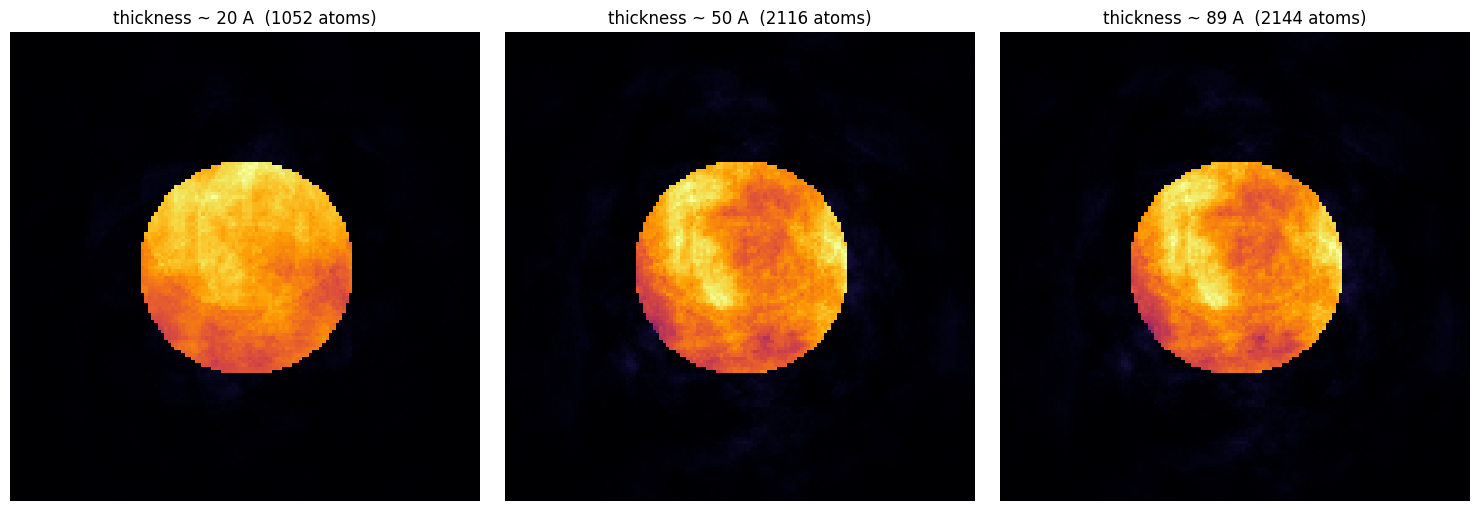

In [11]:
thicknesses = [20.0, 50.0, 89.0]   # Angstrom

fig, axs = plt.subplots(1, len(thicknesses), figsize=(5 * len(thicknesses), 5))
for ax, zt in zip(axs, thicknesses):
    sub, n = square_column(region_side, z_thickness=zt)
    pot_t = simul.kirkland_potentials_crystal(
        sub, pixel_size=pixel_size, slice_thickness=slice_thickness,
        padding=4.0, supersampling=4,
    )
    Ht, Wt, _ = pot_t.slices.shape
    probe_t = simul.make_probe(
        aperture=aperture_mrad, voltage=voltage_kv,
        image_size=jnp.array([Ht, Wt]), calibration_pm=pixel_size * 100.0,
    )
    beam_t = make_probe_modes(
        modes=probe_t[..., None], weights=jnp.array([1.0]), calib=pixel_size,
    )
    img = np.asarray(simul.cbed(pot_slices=pot_t, beam=beam_t, voltage_kv=voltage_kv).data_array)
    cy, cx, r = img.shape[0] // 2, img.shape[1] // 2, 70
    ax.imshow(np.log1p(img[cy - r:cy + r, cx - r:cx + r]), cmap="inferno")
    ax.set_title(f"thickness ~ {zt:.0f} A  ({n} atoms)")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Frozen-lattice snapshots at different temperatures

Each file is a **single** molecular-dynamics configuration of the slab equilibrated
at a given temperature, so the atomic displacements in it already encode the thermal
motion. We use the *static* Kirkland potential (no Debye&ndash;Waller smearing, no
absorptive term), so those displacements are the **only** thermal effect &mdash;
nothing is double counted.

> **This is not a TDS calculation.** Thermal diffuse scattering is the *ensemble
> average* of the diffracted intensity over many independent configurations at a
> **fixed** temperature (the frozen-phonon method). A single configuration gives a
> coherent, speckled pattern, not the smooth averaged background. This dataset
> provides only one snapshot per temperature, so the panels below show the
> *qualitative* trend &mdash; more thermal disorder pushes intensity out of the
> sharp coherent features into a broader diffuse distribution &mdash; rather than a
> quantitative TDS. To compute real TDS you would average the `cbed` intensities
> over many snapshots at the *same* temperature.

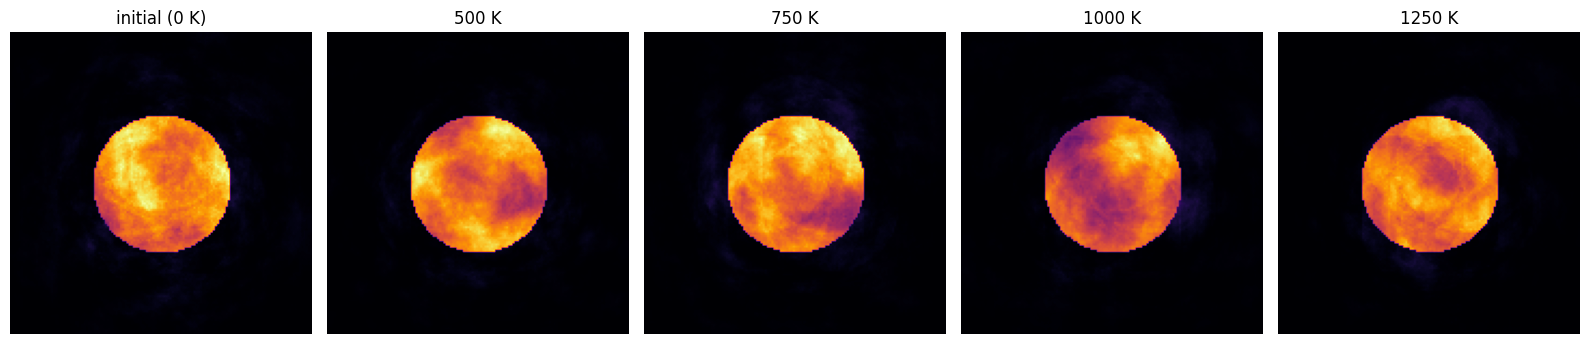

In [12]:
snapshots = [
    ("intial.xyz", "initial (0 K)"),
    ("500K.final.xyz", "500 K"),
    ("750K.final.xyz", "750 K"),
    ("1000K.final.xyz", "1000 K"),
    ("1250K.final.xyz", "1250 K"),
]

fig, axs = plt.subplots(1, len(snapshots), figsize=(3.2 * len(snapshots), 3.4))
for ax, (fname, label) in zip(axs, snapshots):
    snap = simul.parse_xyz(data_dir / fname)
    sp = np.asarray(snap.positions)
    sz = np.asarray(snap.atomic_numbers)
    x0, y0 = sp[:, 0].min(), sp[:, 1].min()
    m = (
        (sp[:, 0] >= x0) & (sp[:, 0] < x0 + region_side)
        & (sp[:, 1] >= y0) & (sp[:, 1] < y0 + region_side)
    )
    col = make_crystal_data(
        positions=jnp.asarray(sp[m]), atomic_numbers=jnp.asarray(sz[m]),
        lattice=snap.lattice, stress=None, energy=None, properties=None, comment=None,
    )
    pot_s = simul.kirkland_potentials_crystal(
        col, pixel_size=pixel_size, slice_thickness=slice_thickness,
        padding=4.0, supersampling=4,
    )
    Hs, Ws, _ = pot_s.slices.shape
    probe_s = simul.make_probe(
        aperture=aperture_mrad, voltage=voltage_kv,
        image_size=jnp.array([Hs, Ws]), calibration_pm=pixel_size * 100.0,
    )
    beam_s = make_probe_modes(modes=probe_s[..., None], weights=jnp.array([1.0]), calib=pixel_size)
    img = np.asarray(simul.cbed(pot_slices=pot_s, beam=beam_s, voltage_kv=voltage_kv).data_array)
    cy, cx, r = img.shape[0] // 2, img.shape[1] // 2, 70
    ax.imshow(np.log1p(img[cy - r:cy + r, cx - r:cx + r]), cmap="inferno")
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Where to go next

- **Aberrations / focal series.** `make_probe` takes `defocus`, `c3`, `c5`. Sweep
  `defocus` to see the probe and CBED change.
- **Partial coherence.** Decompose the probe into mutually incoherent modes with
  `simul.decompose_beam_to_modes` and pass the resulting `ProbeModes` to `cbed`.
- **4D-STEM.** Scan the probe over many positions with `simul.stem_4d`
  (it `vmap`s `cbed` over probe positions) and form virtual-detector images with
  `simul.annular_detector`.